In [10]:

import importlib
import sys
if 'environment' in sys.modules:
    del sys.modules['environment']
import environment
from environment import WumpusWorldEnvironment
importlib.reload(environment)
from environment import WumpusWorldEnvironment

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim) 
        )

    def forward(self, x):
        return self.fc(x)

In [12]:

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    
    def push(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        """
        beta: 采样权重的修正系数 (随着训练增加，逐步从 0.4 增加到 1.0)
        """
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()  
        
        
        states, actions, rewards, next_states, dones = zip(*samples)
        
        return (np.array(states, dtype=np.float32), 
                np.array(actions, dtype=np.int64), 
                np.array(rewards, dtype=np.float32), 
                np.array(next_states, dtype=np.float32), 
                np.array(dones, dtype=np.float32), 
                indices, 
                np.array(weights, dtype=np.float32))

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio + 1e-6

    def __len__(self):
        return len(self.buffer)

In [13]:
class PER_DQNAgent:
    def __init__(self, state_dim, action_dim, device="cpu", use_double=True):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.device = device
        self.use_double = use_double  # Part III 的核心开关
        
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = PrioritizedReplayBuffer(capacity=10000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996
        self.epsilon_min = 0.01
        self.beta = 0.4  
        self.beta_increment = 0.001

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
            return q_values.argmax().item()

    def update(self, batch_size):
        if len(self.memory) < batch_size:
            return None
        
        states, actions, rewards, next_states, dones, indices, weights = \
            self.memory.sample(batch_size, beta=self.beta)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        weights = torch.FloatTensor(weights).to(self.device)

        # 当前 Q 值
        current_q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            if self.use_double:
                # --- Double DQN 核心逻辑 ---
                # 1. 使用 Policy Net 选择下一步的最佳动作索引 (Argmax)
                next_actions = self.policy_net(next_states).max(1)[1].unsqueeze(1)
                # 2. 使用 Target Net 计算该动作的 Q 值 (Evaluate)
                next_q = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            else:
                # --- Vanilla DQN 逻辑 ---
                next_q = self.target_net(next_states).max(1)[0]
                
            target_q = rewards + (1 - dones) * self.gamma * next_q

        # 计算 TD误差用于更新 PER 优先级
        td_errors = torch.abs(target_q - current_q.squeeze()).detach()
        self.memory.update_priorities(indices, td_errors.cpu().numpy())

        # 使用 Huber Loss 或带权重的 MSE
        loss = (weights * (current_q.squeeze() - target_q).pow(2)).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.beta = min(1.0, self.beta + self.beta_increment) 
        
        return loss.item()

print("Double DQN (PER) Agent is ready.")


Double DQN (PER) Agent is ready.


In [14]:
# 确保这段代码左侧没有空格（不属于任何 class）
def optimize_model(env, agent, num_episodes, batch_size, target_update_freq):
    total_rewards = []
    total_losses = []
    
    # 打印当前使用的算法模式
    mode = "Double DQN" if getattr(agent, 'use_double', False) else "Vanilla DQN"
    print(f"Starting training using {mode}...")
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_loss = []
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            # 存入经验
            agent.memory.push(state, action, reward, next_state, done)
            
            # 执行更新逻辑 (内部已包含 Double DQN 逻辑)
            loss = agent.update(batch_size) 
            if loss is not None:
                episode_loss.append(loss)
                
            state = next_state
            episode_reward += reward
            
        # 定期更新目标网络
        if episode % target_update_freq == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())
            
        total_rewards.append(episode_reward)
        total_losses.append(np.mean(episode_loss) if episode_loss else 0)
        
        if (episode + 1) % 20 == 0:
            print(f"Episode {episode+1}/{num_episodes}, Reward: {episode_reward:.2f}, Epsilon: {agent.epsilon:.3f}")
        
    return total_rewards, total_losses

In [15]:
# Grid-world
import numpy as np
from environment import WumpusWorldEnvironment

env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')

obs_sample, _ = env_grid.reset()

if isinstance(obs_sample, (int, np.integer)):
    grid_obs_dim = 1 
else:
    grid_obs_dim = len(obs_sample)

grid_action_dim = env_grid.action_space.n
print(f"Grid-world initialized. State dim: {grid_obs_dim}, Action dim: {grid_action_dim}")


Grid-world initialized. State dim: 2, Action dim: 4


开始训练 Wumpus World... 状态维度: 2, 动作维度: 4
Starting training using Double DQN...
Episode 20/200, Reward: -112.00, Epsilon: 0.343
Episode 40/200, Reward: -103.00, Epsilon: 0.179
Episode 60/200, Reward: -103.00, Epsilon: 0.113
Episode 80/200, Reward: -103.00, Epsilon: 0.078
Episode 100/200, Reward: -103.00, Epsilon: 0.056
Episode 120/200, Reward: -103.00, Epsilon: 0.040
Episode 140/200, Reward: -103.00, Epsilon: 0.027
Episode 160/200, Reward: -101.00, Epsilon: 0.021
Episode 180/200, Reward: -103.00, Epsilon: 0.015
Episode 200/200, Reward: -101.00, Epsilon: 0.010


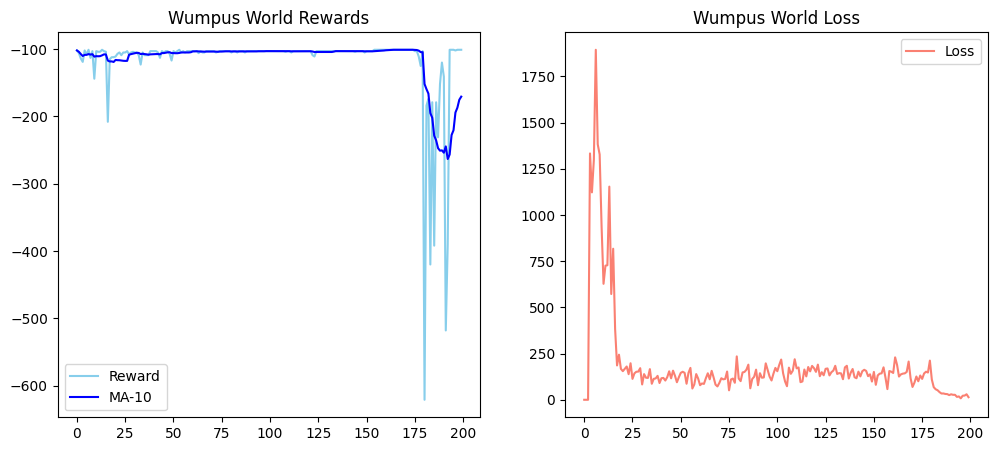

In [16]:
# Run Grid-world

# --- 第 14 个 Cell 完整代码 ---

# 1. 检查并初始化环境
try:
    state, _ = env_grid.reset()
except NameError:
    from environment import WumpusWorldEnvironment
    env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')
    state, _ = env_grid.reset()

# 2. 自动获取维度
grid_obs_dim = np.prod(state.shape)
grid_action_dim = env_grid.action_space.n

# 3. 实例化代理（确保 PER_DQNAgent 已被定义）
agent_grid = PER_DQNAgent(
    state_dim=grid_obs_dim, 
    action_dim=grid_action_dim, 
    device=device
)

print(f"开始训练 Wumpus World... 状态维度: {grid_obs_dim}, 动作维度: {grid_action_dim}")

# 4. 执行训练
grid_rewards, grid_losses = optimize_model(
    env=env_grid, 
    agent=agent_grid, 
    num_episodes=200, 
    batch_size=32, 
    target_update_freq=10
)

# 5. 绘图
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(grid_rewards, color='skyblue', label='Reward')
if len(grid_rewards) > 10:
    ma = [np.mean(grid_rewards[max(0, i-10):i+1]) for i in range(len(grid_rewards))]
    plt.plot(ma, color='blue', label='MA-10')
plt.title("Wumpus World Rewards")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(grid_losses, color='salmon', label='Loss')
plt.title("Wumpus World Loss")
plt.legend()
plt.show()

In [17]:

env_cp = gym.make("CartPole-v1")

cp_state_dim = env_cp.observation_space.shape[0] 
cp_action_dim = env_cp.action_space.n        

print(f"CartPole dimension: State={cp_state_dim}, Action={cp_action_dim}")

agent_cp = PER_DQNAgent(state_dim=cp_state_dim, action_dim=cp_action_dim, device=device)

print("Start training CartPole-v1 (PER-DQN)...")
cp_rewards, cp_losses = optimize_model(env_cp, agent_cp, num_episodes=400, batch_size=64, target_update_freq=15)

env_cp.close()
print("CartPole training over！")

CartPole dimension: State=4, Action=2
Start training CartPole-v1 (PER-DQN)...
Starting training using Double DQN...
Episode 20/400, Reward: 12.00, Epsilon: 0.299
Episode 40/400, Reward: 20.00, Epsilon: 0.090
Episode 60/400, Reward: 93.00, Epsilon: 0.010
Episode 80/400, Reward: 158.00, Epsilon: 0.010
Episode 100/400, Reward: 241.00, Epsilon: 0.010
Episode 120/400, Reward: 191.00, Epsilon: 0.010
Episode 140/400, Reward: 168.00, Epsilon: 0.010
Episode 160/400, Reward: 134.00, Epsilon: 0.010
Episode 180/400, Reward: 139.00, Epsilon: 0.010
Episode 200/400, Reward: 193.00, Epsilon: 0.010
Episode 220/400, Reward: 126.00, Epsilon: 0.010
Episode 240/400, Reward: 133.00, Epsilon: 0.010
Episode 260/400, Reward: 174.00, Epsilon: 0.010
Episode 280/400, Reward: 154.00, Epsilon: 0.010
Episode 300/400, Reward: 149.00, Epsilon: 0.010
Episode 320/400, Reward: 151.00, Epsilon: 0.010
Episode 340/400, Reward: 144.00, Epsilon: 0.010
Episode 360/400, Reward: 143.00, Epsilon: 0.010
Episode 380/400, Reward: 14

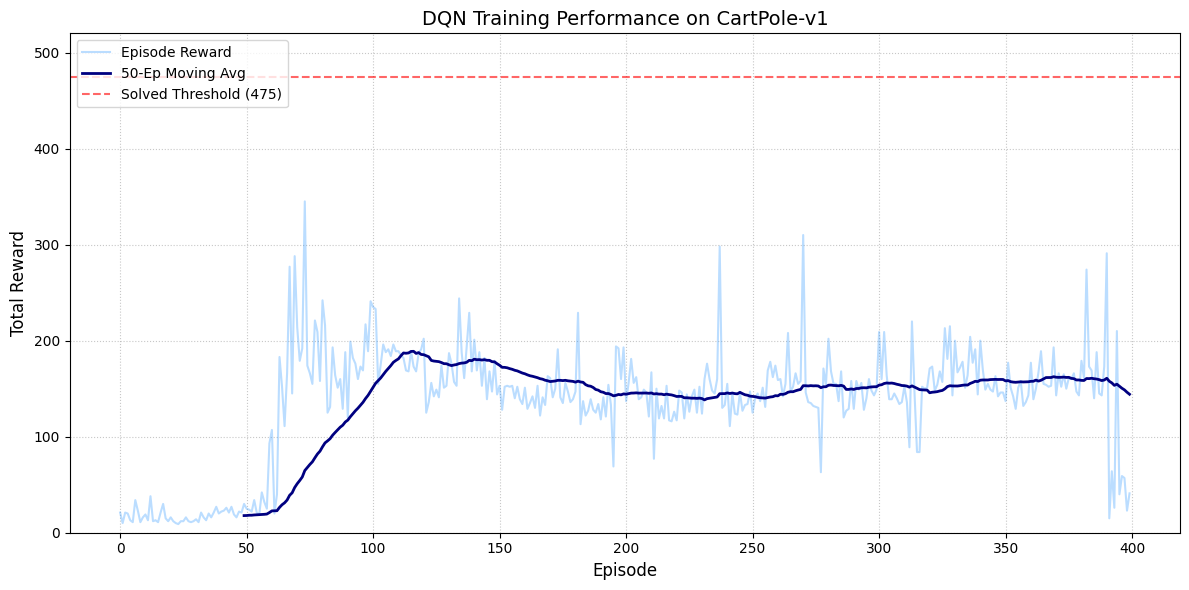

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cartpole_results(rewards):
    plt.figure(figsize=(12, 6))
    
    # 绘制原始奖励曲线（浅色，增加透明度以防干扰）
    plt.plot(rewards, color='dodgerblue', alpha=0.3, label='Episode Reward')
    
    # 计算并绘制滑动平均线（更平滑地观察趋势）
    window_size = 50  # 窗口大小，可根据训练长度调整
    if len(rewards) > window_size:
        # 使用 numpy 计算简单移动平均
        moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        # 补齐长度以便在图中对齐
        plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                 color='navy', linewidth=2, label=f'{window_size}-Ep Moving Avg')
    
    # 标注 CartPole-v1 的目标线（通常 475+ 分被视为解决环境）
    plt.axhline(y=475, color='red', linestyle='--', alpha=0.6, label='Solved Threshold (475)')
    
    # 完善图表信息
    plt.title("DQN Training Performance on CartPole-v1", fontsize=14)
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Total Reward", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # 限制 y 轴范围（CartPole-v1 最大通常是 500）
    plt.ylim(0, 520) 
    
    plt.tight_layout()
    plt.show()

# 假设你在 Cell 8 中保存奖励的变量名为 cp_rewards
# 请确保变量名与 Cell 8 实际定义的一致
plot_cartpole_results(cp_rewards)

In [20]:

env_acro = gym.make("Acrobot-v1")

acro_s_dim = env_acro.observation_space.shape[0] 
acro_a_dim = env_acro.action_space.n 

print(f"Acrobot dimention: State={acro_s_dim}, Action={acro_a_dim}")

agent_acro = PER_DQNAgent(state_dim=acro_s_dim, action_dim=acro_a_dim, device=device)

print("Start training Acrobot-v1 (PER-DQN)...")

cp_rewards, cp_losses = optimize_model(env_cp, agent_cp, num_episodes=400, batch_size=64, target_update_freq=15)

env_acro.close()

Acrobot dimention: State=6, Action=3
Start training Acrobot-v1 (PER-DQN)...
Starting training using Double DQN...
Episode 20/400, Reward: 180.00, Epsilon: 0.010
Episode 40/400, Reward: 236.00, Epsilon: 0.010
Episode 60/400, Reward: 176.00, Epsilon: 0.010
Episode 80/400, Reward: 174.00, Epsilon: 0.010
Episode 100/400, Reward: 199.00, Epsilon: 0.010
Episode 120/400, Reward: 203.00, Epsilon: 0.010
Episode 140/400, Reward: 214.00, Epsilon: 0.010
Episode 160/400, Reward: 154.00, Epsilon: 0.010
Episode 180/400, Reward: 126.00, Epsilon: 0.010
Episode 200/400, Reward: 267.00, Epsilon: 0.010
Episode 220/400, Reward: 246.00, Epsilon: 0.010
Episode 240/400, Reward: 229.00, Epsilon: 0.010
Episode 260/400, Reward: 204.00, Epsilon: 0.010
Episode 280/400, Reward: 233.00, Epsilon: 0.010
Episode 300/400, Reward: 249.00, Epsilon: 0.010
Episode 320/400, Reward: 329.00, Epsilon: 0.010
Episode 340/400, Reward: 259.00, Epsilon: 0.010
Episode 360/400, Reward: 211.00, Epsilon: 0.010
Episode 380/400, Reward: 5

In [21]:
def plot_acrobot_results(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, color='purple', alpha=0.3, label='Episode Reward')
    
    ma_range = 20
    if len(rewards) > ma_range:
        smooth = [np.mean(rewards[max(0, i-ma_range):i+1]) for i in range(len(rewards))]
        plt.plot(smooth, color='darkviolet', linewidth=2, label='Moving Average')
    
    plt.title("PER-DQN on Acrobot-v1: The Two-Link Challenge")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward (Negative is worse)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_acrobot_results(acro_rewards)

NameError: name 'acro_rewards' is not defined